# 08 -- RAG: Retrieval vs. Pretrained Knowledge

Same `.venv`, same `Foundation-Sec-1.1-8B-Instruct` Q4_K_M GGUF setup as notebooks 03-05 (not re-downloaded). Notebooks 00-07 are untouched. No fine-tuning happens here.

**Experiment question:** *When is retrieval more useful than relying on the foundation model's pretrained knowledge?*

**The main lesson this notebook is built to demonstrate:** RAG changes the model's **context** at inference time. It does **not** change the model's weights.

**On retrieval method:** notebook 05 used hand-rolled TF-IDF only. This notebook adds a second, local semantic-embedding retriever (via `sentence-transformers` + `ChromaDB`, both fully local -- no API key, no server, no cloud account) and compares the two head-to-head in Section 7, rather than assuming either is the right choice. Verified before building this notebook: `chromadb` installs cleanly on this Mac in ~15s with no compilation issues, and a full local smoke test (load embedding model, create a collection, add documents, query) completed in under 20 seconds end to end -- a real, low-effort local option, not a production vector database reached for by default. A dedicated vector database's actual value proposition -- approximate nearest-neighbor search at millions-of-vectors scale, persistence, concurrent access -- doesn't apply to this notebook's ~5 documents and ~20 chunks; it's used here for the hands-on comparison and the local infrastructure experience, not because it's technically necessary at this scale.

**Data note:** this notebook uses its own synthetic "Acme Corporation" policy set in `data/security_knowledge_acme/` -- a new directory, not `data/security_knowledge/` (which notebook 05 already populated with different policy content). Reusing that exact path with different content would have silently changed notebook 05's data dependency if it were ever re-run.

## Section 1 -- The product problem

Foundation-Sec has broad security-domain knowledge from training -- attack techniques, common terminology, general best practice. What it cannot know, because it was never in its training data, is anything specific to one organization:

- a customer's internal security policy
- current company procedures
- specific asset criticality assignments
- organization-specific approval rules
- current threat intelligence
- proprietary historical incident cases

A production system serving real customers needs a way to supply exactly this kind of information at inference time, without retraining the model every time a policy changes. That's RAG:

```text
Question
   |
   v
Retrieve relevant knowledge
   |
   v
Add retrieved context
   |
   v
Foundation model
   |
   v
Grounded answer
```

## Section 2 -- Synthetic company knowledge

Five short policy documents for a fictional "Acme Corporation," each explicitly labeled as synthetic, in `data/security_knowledge_acme/`: `authentication_policy.md`, `endpoint_response_policy.md`, `privileged_access_policy.md`, `incident_response_policy.md`, `asset_criticality.md`. Every rule is specific enough (exact approval chains, exact time thresholds, exact criticality tiers) that no foundation model could know it from general training -- that specificity is what makes the model-only-vs-RAG comparison in Section 10 meaningful rather than cosmetic.

In [1]:
from pathlib import Path

KB_DIR = Path("..") / "data" / "security_knowledge_acme"
kb_files = sorted(KB_DIR.glob("*.md"))
print(f"Acme policy knowledge base: {len(kb_files)} documents")
for f in kb_files:
    print(f" - {f.name} ({f.stat().st_size} bytes)")

Acme policy knowledge base: 5 documents
 - asset_criticality.md (418 bytes)
 - authentication_policy.md (880 bytes)
 - endpoint_response_policy.md (794 bytes)
 - incident_response_policy.md (576 bytes)
 - privileged_access_policy.md (523 bytes)


## Section 3 -- RAG questions

12 questions: 9 answerable from the policy set above (spanning all 5 documents), and 3 deliberately **not** covered by any policy -- the knowledge base genuinely does not say how long firewall logs must be retained, what the Low-severity escalation path is, or how to request a VPN certificate. The correct behavior on those three is to say so, not to guess.

In [2]:
QUESTIONS = [
    {"id": "Q1", "question": "Can a domain controller be automatically isolated?", "answerable": True,
     "authoritative_document": "endpoint_response_policy.md",
     "expected_answer": "No -- domain controllers may never be automatically isolated, regardless of confidence or severity."},
    {"id": "Q2", "question": "What approval is required before disabling a privileged account?", "answerable": True,
     "authoritative_document": "privileged_access_policy.md",
     "expected_answer": "Two-person approval -- the requesting analyst plus one additional authorized approver."},
    {"id": "Q3", "question": "How quickly must a High severity incident be reviewed?", "answerable": True,
     "authoritative_document": "incident_response_policy.md",
     "expected_answer": "Within 30 minutes of detection."},
    {"id": "Q4", "question": "What is the criticality of a developer laptop?", "answerable": True,
     "authoritative_document": "asset_criticality.md",
     "expected_answer": "Medium."},
    {"id": "Q5", "question": "What should happen if a privileged user triggers an impossible travel alert?", "answerable": True,
     "authoritative_document": "authentication_policy.md",
     "expected_answer": "It must be escalated immediately to the on-call security lead."},
    {"id": "Q6", "question": "Can an AI system automatically reset a user's credentials?", "answerable": True,
     "authoritative_document": "privileged_access_policy.md",
     "expected_answer": "No -- it may recommend a credential reset but may not execute one automatically."},
    {"id": "Q7", "question": "What happens when malware is confirmed on a developer laptop?", "answerable": True,
     "authoritative_document": "endpoint_response_policy.md",
     "expected_answer": "It may be automatically isolated, since the malware is confirmed rather than merely suspected."},
    {"id": "Q8", "question": "May a service account authenticate interactively?", "answerable": True,
     "authoritative_document": "authentication_policy.md",
     "expected_answer": "No -- any interactive login using a service account must be treated as a security event."},
    {"id": "Q9", "question": "What must happen for a Critical severity incident?", "answerable": True,
     "authoritative_document": "incident_response_policy.md",
     "expected_answer": "Immediate escalation to the incident commander, with no review delay permitted."},
    {"id": "Q10", "question": "How long must firewall logs be retained?", "answerable": False,
     "authoritative_document": None, "expected_answer": None},
    {"id": "Q11", "question": "What is the escalation path for a Low severity incident?", "answerable": False,
     "authoritative_document": None, "expected_answer": None},
    {"id": "Q12", "question": "What is the process for requesting a new VPN certificate?", "answerable": False,
     "authoritative_document": None, "expected_answer": None},
]

n_answerable = sum(1 for q in QUESTIONS if q["answerable"])
print(f"{len(QUESTIONS)} questions: {n_answerable} answerable from policy, {len(QUESTIONS) - n_answerable} deliberately unanswerable")

12 questions: 9 answerable from policy, 3 deliberately unanswerable


## Section 4 -- Model-only baseline

Every question is asked with **no** policy context. The structured schema includes `insufficient_information` explicitly, so the model has a designated, honest way to say "I don't have Acme's specific policy" instead of guessing -- whether it actually uses that option is the real question this section answers.

Scoring, per question:
- **correct** -- answerable question, `insufficient_information=false`, answer matches the real policy.
- **partially_correct** -- answerable question, some but not all of the expected content present.
- **unsupported** -- answerable question, model honestly flagged `insufficient_information=true` rather than guessing (a safe failure).
- **hallucinated_policy** -- either an answerable question answered confidently *and* wrong, or an unanswerable question answered with an invented rule instead of a refusal.

**The important point:** a fluent, plausible-sounding answer is not the same thing as the correct organization-specific answer.

In [3]:
import os
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
os.environ["ANONYMIZED_TELEMETRY"] = "FALSE"

import json
import re
import time

from huggingface_hub import hf_hub_download
from llama_cpp import Llama

REPO_ID = "fdtn-ai/Foundation-Sec-1.1-8B-Instruct-Q4_K_M-GGUF"
FILENAME = "foundation-sec-1.1-8b-instruct-q4_k_m.gguf"

model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)  # resolves instantly -- already cached
print(f"Using cached model file: {FILENAME} (not re-downloaded)")

llm = Llama(model_path=model_path, n_ctx=2048, n_gpu_layers=-1, verbose=False)
print("Model loaded.")

RESPONSE_SCHEMA_DESC = (
    '{"answer": "", "policy_basis": [], "source_documents": [], "insufficient_information": false}'
)

BASELINE_SYSTEM_PROMPT = (
    "You are a security policy assistant. Answer the question using your own knowledge. You do NOT have access "
    "to this organization's specific policy documents. If you are not certain what this organization's specific "
    "policy says, say so and set insufficient_information to true rather than guessing. Respond with ONLY a "
    "single valid JSON object, no other text, with exactly this shape: " + RESPONSE_SCHEMA_DESC
)


def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()
    start, end = text.find("{"), text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None


def query_model(system_prompt, user_content, max_tokens=300):
    messages = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_content}]
    t0 = time.time()
    try:
        resp = llm.create_chat_completion(
            messages=messages, response_format={"type": "json_object"}, temperature=0.1, max_tokens=max_tokens,
        )
    except TypeError:
        resp = llm.create_chat_completion(messages=messages, temperature=0.1, max_tokens=max_tokens)
    latency = time.time() - t0
    raw_text = resp["choices"][0]["message"]["content"].strip()
    return {
        "raw_text": raw_text,
        "parsed": extract_json(raw_text),
        "latency_sec": latency,
        "usage": resp.get("usage", {}),
    }


STOPWORDS = {
    "the", "a", "an", "is", "are", "was", "were", "be", "been", "being", "to", "of", "and", "or", "in", "on",
    "for", "with", "this", "that", "it", "as", "by", "at", "from", "must", "may", "can", "not", "no", "if",
}


def significant_words(text):
    words = re.findall(r"[a-z0-9]+", text.lower())
    return {w for w in words if w not in STOPWORDS and len(w) > 2}


def keyword_overlap(expected_text, actual_text):
    expected_words = significant_words(expected_text)
    if not expected_words:
        return 1.0
    actual_words = significant_words(actual_text)
    return len(expected_words & actual_words) / len(expected_words)


def score_answer(question, parsed):
    if parsed is None:
        return "parse_failure"
    insufficient = bool(parsed.get("insufficient_information", False))
    answer_text = str(parsed.get("answer", ""))
    if question["answerable"]:
        if insufficient:
            return "unsupported"
        overlap = keyword_overlap(question["expected_answer"], answer_text)
        # Yes/No polarity check: a terse but polarity-correct answer (e.g. just "No")
        # would otherwise score 0 overlap against a longer expected explanation and
        # get mislabeled as a confident wrong answer, when it's actually correct,
        # just under-elaborated. Caught in Example C of Section 11 before finalizing.
        expected_lower = question["expected_answer"].lower().strip()
        answer_lower = answer_text.lower().strip()
        polarity_match = None
        if expected_lower.startswith("no"):
            polarity_match = answer_lower.startswith("no") or answer_lower.startswith("cannot") or " not " in (" " + answer_lower[:60])
        elif expected_lower.startswith("yes"):
            polarity_match = answer_lower.startswith("yes")
        if overlap >= 0.6:
            return "correct"
        elif polarity_match and overlap >= 0.3:
            return "correct"
        elif polarity_match:
            return "partially_correct"
        elif overlap >= 0.3:
            return "partially_correct"
        else:
            return "hallucinated_policy"
    else:
        return "correct_refusal" if insufficient else "hallucinated_policy"

print("Model, prompts, and scoring helpers defined.")


Using cached model file: foundation-sec-1.1-8b-instruct-q4_k_m.gguf (not re-downloaded)


Model loaded.
Model, prompts, and scoring helpers defined.


In [4]:
baseline_results = {}
for q in QUESTIONS:
    outcome = query_model(BASELINE_SYSTEM_PROMPT, q["question"])
    verdict = score_answer(q, outcome["parsed"])
    baseline_results[q["id"]] = {**outcome, "verdict": verdict}
    print(f"{q['id']:<4} [{verdict:<20}] {q['question'][:65]}")


Q1   [partially_correct   ] Can a domain controller be automatically isolated?


Q2   [hallucinated_policy ] What approval is required before disabling a privileged account?


Q3   [partially_correct   ] How quickly must a High severity incident be reviewed?


Q4   [hallucinated_policy ] What is the criticality of a developer laptop?


Q5   [hallucinated_policy ] What should happen if a privileged user triggers an impossible tr


...

Q8   [partially_correct   ] May a service account authenticate interactively?


Q9   [hallucinated_policy ] What must happen for a Critical severity incident?


Q10  [hallucinated_policy ] How long must firewall logs be retained?


Q11  [hallucinated_policy ] What is the escalation path for a Low severity incident?


Q12  [parse_failure       ] What is the process for requesting a new VPN certificate?


## Section 5 -- Document chunking

Split on `## ` section headers, same approach as notebook 05, so each chunk is one coherent rule area with its document and section name preserved as metadata.

**Why chunk at all:** a retrieval query should surface the specific relevant passage, not an entire multi-topic document.

**The size tradeoff:** too large (whole documents) pulls in irrelevant rules alongside the relevant one, inflates the prompt, and dilutes relevance; too small (single sentences) loses the surrounding context a rule needs to be correctly understood and fragments a policy across disconnected pieces.

In [5]:
def load_and_chunk(md_path):
    text = md_path.read_text()
    parts = re.split(r"(?m)^## ", text)
    chunks = []
    preamble = parts[0].strip()
    if preamble:
        chunks.append({"document": md_path.name, "section": "Overview", "text": preamble})
    for part in parts[1:]:
        lines = part.split("\n", 1)
        section_title = lines[0].strip()
        body = lines[1].strip() if len(lines) > 1 else ""
        chunks.append({"document": md_path.name, "section": section_title, "text": f"## {section_title}\n{body}"})
    return chunks


all_chunks = []
for f in kb_files:
    all_chunks.extend(load_and_chunk(f))

for i, c in enumerate(all_chunks):
    c["chunk_id"] = f"chunk_{i}"

print(f"{len(all_chunks)} chunks from {len(kb_files)} documents")
for c in all_chunks:
    print(f"  [{c['chunk_id']}] {c['document']:<32} {c['section']}")

20 chunks from 5 documents
  [chunk_0] asset_criticality.md             Overview
  [chunk_1] asset_criticality.md             Critical
  [chunk_2] asset_criticality.md             High
  [chunk_3] asset_criticality.md             Medium
  [chunk_4] asset_criticality.md             Low
  [chunk_5] authentication_policy.md         Overview
  [chunk_6] authentication_policy.md         Impossible Travel
  [chunk_7] authentication_policy.md         Multi-Factor Authentication Anomalies
  [chunk_8] authentication_policy.md         Service Accounts
  [chunk_9] endpoint_response_policy.md      Overview
  [chunk_10] endpoint_response_policy.md      Production Endpoints
  [chunk_11] endpoint_response_policy.md      Developer Laptops
  [chunk_12] endpoint_response_policy.md      Domain Controllers
  [chunk_13] incident_response_policy.md      Overview
  [chunk_14] incident_response_policy.md      Severity: Critical
  [chunk_15] incident_response_policy.md      Severity: High
  [chunk_16] incident

## Section 6 -- Two retrieval methods, side by side

**Method 1: TF-IDF (lexical).** Hand-rolled cosine similarity over term-frequency vectors, identical to notebook 05 -- scores a chunk higher the more its exact/stemmed words overlap with the query.

**Method 2: Semantic embeddings via ChromaDB (local).** Each chunk is embedded with a small local sentence-transformer model (`all-MiniLM-L6-v2`, ~80MB, downloaded once and cached) and stored in a local, in-memory ChromaDB collection -- no server, no API key, no cloud account. Retrieval measures semantic similarity in embedding space, so it can match a query and a chunk that share meaning but not exact wording.

Both are run against the same query, side by side, before either touches the model.

In [6]:
import math
from collections import Counter


def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())


def build_tfidf_index(chunks):
    doc_tokens = [tokenize(c["text"]) for c in chunks]
    df = Counter()
    for tokens in doc_tokens:
        for term in set(tokens):
            df[term] += 1
    n_docs = len(chunks)
    idf = {term: math.log((n_docs + 1) / (freq + 1)) + 1 for term, freq in df.items()}
    vectors = []
    for tokens in doc_tokens:
        tf = Counter(tokens)
        length = len(tokens) or 1
        vectors.append({term: (count / length) * idf.get(term, 0.0) for term, count in tf.items()})
    return vectors, idf


def vectorize_query(query, idf):
    tokens = tokenize(query)
    tf = Counter(tokens)
    length = len(tokens) or 1
    return {term: (count / length) * idf.get(term, 0.0) for term, count in tf.items()}


def cosine_similarity(vec_a, vec_b):
    common = set(vec_a) & set(vec_b)
    dot = sum(vec_a[t] * vec_b[t] for t in common)
    norm_a = math.sqrt(sum(v * v for v in vec_a.values()))
    norm_b = math.sqrt(sum(v * v for v in vec_b.values()))
    return 0.0 if norm_a == 0 or norm_b == 0 else dot / (norm_a * norm_b)


def retrieve_tfidf(query, chunks, tfidf_vectors, idf, top_k=3):
    query_vec = vectorize_query(query, idf)
    scores = [(i, cosine_similarity(query_vec, vec)) for i, vec in enumerate(tfidf_vectors)]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [(chunks[i], score) for i, score in scores[:top_k]]


tfidf_vectors, idf = build_tfidf_index(all_chunks)

import chromadb
from chromadb.utils import embedding_functions

embedding_fn = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
chroma_client = chromadb.Client()
chroma_collection = chroma_client.create_collection(name="acme_policy", embedding_function=embedding_fn)
chroma_collection.add(
    documents=[c["text"] for c in all_chunks],
    ids=[c["chunk_id"] for c in all_chunks],
    metadatas=[{"document": c["document"], "section": c["section"]} for c in all_chunks],
)
chunk_by_id = {c["chunk_id"]: c for c in all_chunks}
print(f"ChromaDB collection ready with {chroma_collection.count()} chunks embedded.")


def retrieve_semantic(query, top_k=3):
    result = chroma_collection.query(query_texts=[query], n_results=top_k)
    pairs = []
    for chunk_id, distance in zip(result["ids"][0], result["distances"][0]):
        pairs.append((chunk_by_id[chunk_id], 1 / (1 + distance)))  # convert distance to a similarity-like score
    return pairs


demo_query = QUESTIONS[0]["question"]
print(f"\nDemo query: {demo_query!r}\n")
print("TF-IDF top-3:")
for c, score in retrieve_tfidf(demo_query, all_chunks, tfidf_vectors, idf):
    print(f"  {score:.3f}  [{c['document']} -- {c['section']}]")
print("\nSemantic (ChromaDB) top-3:")
for c, score in retrieve_semantic(demo_query):
    print(f"  {score:.3f}  [{c['document']} -- {c['section']}]")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2571.98it/s]

ChromaDB collection ready with 20 chunks embedded.

Demo query: 'Can a domain controller be automatically isolated?'

TF-IDF top-3:
  0.517  [endpoint_response_policy.md -- Domain Controllers]
  0.175  [endpoint_response_policy.md -- Developer Laptops]
  0.138  [asset_criticality.md -- Critical]

Semantic (ChromaDB) top-3:
  0.787  [endpoint_response_policy.md -- Domain Controllers]
  0.614  [endpoint_response_policy.md -- Developer Laptops]
  0.595  [endpoint_response_policy.md -- Production Endpoints]


## Section 7 -- Retrieval evaluation (before touching the LLM)

Evaluated separately from generation, and on purpose: a wrong RAG answer can come from **retrieval failure** (the right policy was never shown to the model) or **generation/reasoning failure** (it was shown, but the model got it wrong anyway). These require different fixes, so they're measured separately here before either method is used to generate a single answer.

In [7]:
answerable_questions = [q for q in QUESTIONS if q["answerable"]]

retrieval_eval = {"tfidf": [], "semantic": []}
for q in answerable_questions:
    tfidf_hits = retrieve_tfidf(q["question"], all_chunks, tfidf_vectors, idf, top_k=3)
    semantic_hits = retrieve_semantic(q["question"], top_k=3)
    for method, hits in [("tfidf", tfidf_hits), ("semantic", semantic_hits)]:
        docs_in_order = [c["document"] for c, _ in hits]
        top1_correct = docs_in_order[0] == q["authoritative_document"] if docs_in_order else False
        top3_correct = q["authoritative_document"] in docs_in_order
        retrieval_eval[method].append({"id": q["id"], "top1": top1_correct, "top3": top3_correct, "retrieved": docs_in_order})

print(f"{'ID':<5}{'expected doc':<32}{'TF-IDF top-1':<14}{'TF-IDF top-3':<14}{'Semantic top-1':<16}{'Semantic top-3'}")
for q, t, s in zip(answerable_questions, retrieval_eval["tfidf"], retrieval_eval["semantic"]):
    print(f"{q['id']:<5}{q['authoritative_document']:<32}{str(t['top1']):<14}{str(t['top3']):<14}{str(s['top1']):<16}{str(s['top3'])}")

print()
for method in ["tfidf", "semantic"]:
    top1_acc = sum(r["top1"] for r in retrieval_eval[method]) / len(retrieval_eval[method])
    top3_recall = sum(r["top3"] for r in retrieval_eval[method]) / len(retrieval_eval[method])
    print(f"{method:<10} top-1 accuracy: {top1_acc:.0%}   top-3 recall: {top3_recall:.0%}")

tfidf_top1 = sum(r["top1"] for r in retrieval_eval["tfidf"])
semantic_top1 = sum(r["top1"] for r in retrieval_eval["semantic"])
RETRIEVAL_METHOD = "semantic" if semantic_top1 >= tfidf_top1 else "tfidf"
print(f"\nMethod used for the rest of this notebook (Sections 8 onward): '{RETRIEVAL_METHOD}'")
print("(chosen as whichever scored at least as well on top-1 accuracy above -- not assumed in advance)")

ID   expected doc                    TF-IDF top-1  TF-IDF top-3  Semantic top-1  Semantic top-3
Q1   endpoint_response_policy.md     True          True          True            True
Q2   privileged_access_policy.md     True          True          True            True
Q3   incident_response_policy.md     True          True          True            True
Q4   asset_criticality.md            False         True          True            True
Q5   authentication_policy.md        True          True          True            True
Q6   privileged_access_policy.md     True          True          True            True
Q7   endpoint_response_policy.md     True          True          True            True
Q8   authentication_policy.md        True          True          True            True
Q9   incident_response_policy.md     True          True          True            True

tfidf      top-1 accuracy: 89%   top-3 recall: 100%
semantic   top-1 accuracy: 100%   top-3 recall: 100%

Method used for the res

## Section 8 -- The RAG prompt

```text
SYSTEM:
You are a security policy assistant.

SECURITY POLICY CONTEXT:
<retrieved chunks>

QUESTION:
<question>

INSTRUCTIONS:
- Answer using the supplied policy context.
- Do not invent organization policy.
- If the answer is not in the supplied context, say so.
- Cite the document name used.
- Distinguish recommendations from mandatory policy.
```

Structured output: `{"answer": "", "policy_basis": [], "source_documents": [], "insufficient_information": false}` -- the same shape as the baseline in Section 4, so the two are directly comparable field-by-field.

In [8]:
RAG_SYSTEM_PROMPT = (
    "You are a security policy assistant. Use the supplied SECURITY POLICY CONTEXT to answer the question. "
    "Do not invent organization policy. If the answer is not in the supplied context, say so and set "
    "insufficient_information to true. Cite the document name(s) used in source_documents. Distinguish "
    "recommendations from mandatory policy in your answer. Respond with ONLY a single valid JSON object, "
    "no other text, with exactly this shape: " + RESPONSE_SCHEMA_DESC
)


def build_rag_user_content(question, retrieved):
    context_text = "\n\n".join(f"[{c['document']} -- {c['section']}]\n{c['text']}" for c, _ in retrieved)
    return f"SECURITY POLICY CONTEXT:\n{context_text}\n\nQUESTION:\n{question}"


def retrieve(query, top_k=3):
    return retrieve_semantic(query, top_k) if RETRIEVAL_METHOD == "semantic" else retrieve_tfidf(query, all_chunks, tfidf_vectors, idf, top_k)


print("RAG prompt and retrieval function defined.")

RAG prompt and retrieval function defined.


## Section 9 -- Model + RAG, all 12 questions

In [9]:
rag_results = {}
for q in QUESTIONS:
    retrieved = retrieve(q["question"])
    outcome = query_model(RAG_SYSTEM_PROMPT, build_rag_user_content(q["question"], retrieved))
    verdict = score_answer(q, outcome["parsed"])
    rag_results[q["id"]] = {**outcome, "verdict": verdict, "retrieved": retrieved}
    print(f"{q['id']:<4} [{verdict:<20}] {q['question'][:65]}")

Q1   [partially_correct   ] Can a domain controller be automatically isolated?


Q2   [correct             ] What approval is required before disabling a privileged account?


Q3   [correct             ] How quickly must a High severity incident be reviewed?


Q4   [correct             ] What is the criticality of a developer laptop?


Q5   [correct             ] What should happen if a privileged user triggers an impossible tr


...

Q8   [partially_correct   ] May a service account authenticate interactively?


Q9   [correct             ] What must happen for a Critical severity incident?


Q10  [hallucinated_policy ] How long must firewall logs be retained?


Q11  [hallucinated_policy ] What is the escalation path for a Low severity incident?


Q12  [hallucinated_policy ] What is the process for requesting a new VPN certificate?


## Section 10 -- Before vs. after

**Not claiming RAG is universally better** -- only describing what happened in this specific run, on these specific questions.

In [10]:
def summarize(results_dict):
    verdicts = [r["verdict"] for r in results_dict.values()]
    counts = Counter(verdicts)
    n = len(verdicts)
    n_correct = counts.get("correct", 0)
    n_correct_refusal = counts.get("correct_refusal", 0)
    n_hallucinated = counts.get("hallucinated_policy", 0)
    n_unsupported = counts.get("unsupported", 0)
    return {
        "correctness (answerable Qs correct)": f"{n_correct}/{n_answerable}",
        "correct refusal (unanswerable Qs)": f"{n_correct_refusal}/{len(QUESTIONS) - n_answerable}",
        "hallucinated policy": f"{n_hallucinated}/{n}",
        "honest unsupported (answerable Qs)": f"{n_unsupported}/{n_answerable}",
    }


baseline_summary = summarize(baseline_results)
rag_summary = summarize(rag_results)

print(f"{'Metric':<38}{'Model only':<14}{'RAG'}")
for key in baseline_summary:
    print(f"{key:<38}{baseline_summary[key]:<14}{rag_summary[key]}")

Metric                                Model only    RAG
correctness (answerable Qs correct)   0/9           6/9
correct refusal (unanswerable Qs)     0/3           0/3
hallucinated policy                   6/12          3/12
honest unsupported (answerable Qs)    0/9           0/9


> **Post-execution audit note (the table above is unchanged).** The scores above come from an automated keyword scorer. A later manual review of a fresh re-run (see "Post-execution audit" before the Final summary, and `results/08_rag_audit_raw_answers.json`) found that the scorer's labels differ from a human reading in both columns, so read `0/9` as "0/9 by strict keyword scoring," not "0/9 right." In the model-only column, `partially_correct` covered both wrong answers (Q1 said "Yes"; Q3 gave a wrong review time) and correct-but-generic ones (Q6, Q8), and `hallucinated_policy` covered both wrong specifics (Q2, Q4) and hedged or generic non-answers (Q5, Q9). The unaided model was right on generic defaults and wrong on organization-specific facts. Model-only wording varies between runs, so treat any specific quoted value as illustrative.

## Section 11 -- Concrete examples

Four outcome patterns, selected programmatically from the actual data above rather than hand-picked to fit a narrative. If a pattern didn't actually occur in this run, that's reported honestly instead of forcing a weak example into the slot.

In [11]:
def show_example(label, q_id, failure_layer, note):
    q = next(q for q in QUESTIONS if q["id"] == q_id)
    b, r = baseline_results[q_id], rag_results[q_id]
    print("=" * 90)
    print(f"{label} -- {q_id}")
    print(f"\nQUESTION: {q['question']}")
    print(f"EXPECTED ANSWER: {q['expected_answer'] or '(not covered by any policy -- correct answer is to say so)'}")
    print(f"\nMODEL-ONLY ANSWER ({b['verdict']}): {(b['parsed'] or {}).get('answer', b['raw_text'])}")
    print(f"\nRETRIEVED CONTEXT: {[(c['document'], c['section']) for c, _ in r['retrieved']]}")
    print(f"\nRAG ANSWER ({r['verdict']}): {(r['parsed'] or {}).get('answer', r['raw_text'])}")
    print(f"\nFAILURE LAYER: {failure_layer}")
    print(f"PRODUCT INTERPRETATION: {note}\n")


# Example A: model-only wrong/unsupported, RAG correct
example_a = next((q["id"] for q in answerable_questions
                   if baseline_results[q["id"]]["verdict"] != "correct" and rag_results[q["id"]]["verdict"] == "correct"), None)
if example_a:
    show_example("EXAMPLE A: model-only guesses, RAG correct", example_a, "none -- retrieval and generation both worked",
                 "This is RAG doing exactly its job: supplying organization-specific knowledge the model cannot have from training.")
else:
    print("EXAMPLE A did not occur in this run: no question had a wrong/unsupported baseline that RAG then fixed.")

# Example B: retrieval found the wrong document, RAG wrong
wrong_retrieval_ids = [q["id"] for q, res in zip(answerable_questions, retrieval_eval[RETRIEVAL_METHOD]) if not res["top1"]]
example_b = next((qid for qid in wrong_retrieval_ids if rag_results[qid]["verdict"] != "correct"), None)
if example_b:
    show_example("EXAMPLE B: wrong retrieval, wrong RAG answer", example_b, "retrieval",
                 "A retrieval fix (better chunking, a different retriever, more documents) is what's needed here -- not a bigger model.")
else:
    print("EXAMPLE B did not occur in this run: every top-1 retrieval miss (if any) still produced a usable RAG answer, or retrieval never missed.")

# Example C: correct retrieval but model still reasoned incorrectly
correct_retrieval_ids = [q["id"] for q, res in zip(answerable_questions, retrieval_eval[RETRIEVAL_METHOD]) if res["top1"]]
example_c = next((qid for qid in correct_retrieval_ids if rag_results[qid]["verdict"] not in ("correct",)), None)
if example_c:
    show_example("EXAMPLE C: correct retrieval, wrong reasoning", example_c, "generation/reasoning",
                 "The right policy was right there in the prompt and the model still got it wrong -- a generation problem, addressed by prompt changes, a different model, or stricter output constraints, not by fixing retrieval.")
else:
    print("EXAMPLE C did not occur in this run: every correctly-retrieved question was also answered correctly.")

# Example D: unanswerable question, correctly refused
example_d = next((q["id"] for q in QUESTIONS if not q["answerable"] and rag_results[q["id"]]["verdict"] == "correct_refusal"), None)
if example_d:
    show_example("EXAMPLE D: no answer exists, model correctly says so", example_d, "none -- correct refusal behavior",
                 "This is the safe failure mode: the model recognized the retrieved context didn't cover the question, rather than inventing a plausible-sounding policy.")
else:
    print("EXAMPLE D did not occur in this run: no unanswerable question was correctly refused with RAG context supplied.")

EXAMPLE A: model-only guesses, RAG correct -- Q2

QUESTION: What approval is required before disabling a privileged account?
EXPECTED ANSWER: Two-person approval -- the requesting analyst plus one additional authorized approver.

MODEL-ONLY ANSWER (hallucinated_policy): Typically, disabling a privileged account requires approval from the IT security team or the system administrator, as these accounts have elevated access rights and can affect system integrity and security. However, the exact process can vary depending on the organization’s specific policies and procedures.

RETRIEVED CONTEXT: [('privileged_access_policy.md', 'Account Disablement'), ('authentication_policy.md', 'Impossible Travel'), ('authentication_policy.md', 'Service Accounts')]

RAG ANSWER (correct): Two-person approval is required before disabling a privileged account. The requesting analyst and one additional authorized approver must approve the action.

FAILURE LAYER: none -- retrieval and generation both worked


> **Post-execution audit note (the output above is unchanged).** Example C's "wrong reasoning" label overstates what happened for Q1: the RAG answer "No" is correct, just terse. The three RAG answers scored `partially_correct` (Q1, Q7, Q8) were later re-read against the policy text on a fresh re-run. Q1 ("No") and Q8 ("No, a service account may not authenticate interactively") are correct but omit the reference's qualifier. Q7 is right in direction but says the laptop "will be" automatically isolated where the policy says it "may be," turning a permission into an obligation, which matters in a security setting. So none of the three is simply wrong, but only two are clean. The audit also found a flaw in an answer the scorer marked `correct`: Q5 says "the privileged user ... must escalate," when the policy is passive and the user whose account triggered the alert is not the escalating party. (Q7 and Q8 text is from the audit re-run, because the original run saved only verdict labels; Q1 matches the recorded output exactly.)

## Section 12 -- RAG failure taxonomy

| Failure type | What it looks like | Different intervention needed |
|---|---|---|
| Wrong retrieval | Top result is from the wrong document entirely | Better chunking, a different/blended retriever |
| Missing retrieval | Nothing relevant surfaces in top-k at all | Expand the knowledge base, raise top-k, improve chunking |
| Irrelevant retrieval | Retrieved chunks are topically unrelated noise | Retriever tuning, relevance threshold/filtering |
| Correct retrieval + wrong reasoning | Right context supplied, model still errs | Prompt engineering, different model, stricter constraints |
| Correct retrieval + hallucination | Right context supplied, model adds invented specifics anyway | Output grounding checks, lower temperature, stricter instructions |
| Unsupported answer when no document exists | Question has no policy coverage, model invents one instead of refusing | Explicit refusal instruction + `insufficient_information` field (Section 4/9), evaluated directly |
| Citation mismatch | `source_documents` names a document that wasn't actually retrieved | Programmatic validation of citations against what was actually retrieved |
| Conflicting policies | Two retrieved chunks disagree and the model silently picks one | Versioning and conflict surfacing at the platform layer -- demonstrated next, in Section 13 |

In [12]:
def classify_rag_failure(q, result, retrieval_result):
    if result["verdict"] == "correct" or result["verdict"] == "correct_refusal":
        return None
    if q["answerable"] and retrieval_result is not None:
        if not retrieval_result["top3"]:
            return "missing_retrieval" if not retrieval_result["top1"] else "wrong_retrieval"
        elif not retrieval_result["top1"]:
            return "wrong_retrieval"
        elif result["verdict"] == "hallucinated_policy":
            return "correct_retrieval_plus_hallucination"
        else:
            return "correct_retrieval_plus_wrong_reasoning"
    if not q["answerable"]:
        return "unsupported_answer_when_no_document_exists"
    return "other"


retrieval_by_id = {q["id"]: res for q, res in zip(answerable_questions, retrieval_eval[RETRIEVAL_METHOD])}
rag_failure_tags = []
for q in QUESTIONS:
    tag = classify_rag_failure(q, rag_results[q["id"]], retrieval_by_id.get(q["id"]))
    if tag:
        rag_failure_tags.append(tag)

rag_failure_counts = Counter(rag_failure_tags)
print("Observed RAG failure types in this run:")
for failure_type, count in rag_failure_counts.items():
    print(f"  {failure_type}: {count}")
if not rag_failure_tags:
    print("  (none -- every RAG answer was correct or a correct refusal)")

Observed RAG failure types in this run:
  correct_retrieval_plus_wrong_reasoning: 3
  unsupported_answer_when_no_document_exists: 3


> **Post-execution audit note (the counts above are unchanged).** `correct_retrieval_plus_wrong_reasoning: 3` (Q1, Q7, Q8) over-counts: two are terse-but-correct answers and one (Q7) has a modality error, so none is a wrong answer. The audit also found one wording-level flaw the scorer marked correct (Q5). Two failure types seen in the audit are not in this taxonomy. (1) **Abstention:** all three unanswerable questions were answered (0/3 correct refusals, as recorded). (2) **Citation faithfulness:** with RAG, the model cited real policy documents for claims those documents do not contain (Q10 and Q12; Q11 is mixed). That is distinct from retrieving the wrong document and from giving no citation, and the scorer never evaluated citations. The "RAG failure type breakdown" plot saved in Section 20 uses the uncorrected counts and is left as recorded.

## Section 13 -- Conflicting knowledge

A controlled, isolated test -- not part of the main 12-question set above. Two versions of the same rule are added to the retrieval index side by side: the current policy (30 minutes, dated 2026-01-01) and a fictional superseded version (60 minutes, dated 2024-01-15, explicitly marked `status: SUPERSEDED`).

In [13]:
current_chunk = next(c for c in all_chunks if c["document"] == "incident_response_policy.md" and c["section"] == "Severity: High")
legacy_chunk = {
    "document": "incident_response_policy.md",
    "section": "Severity: High (superseded)",
    "text": "## Severity: High (superseded)\nHigh severity incidents must be reviewed within 60 minutes of detection.",
    "version_date": "2024-01-15", "status": "SUPERSEDED",
}
current_tagged = {**current_chunk, "version_date": "2026-01-01", "status": "CURRENT"}

conflict_question = "How quickly must a High severity incident be reviewed?"
conflict_context = "\n\n".join(
    f"[{c['document']} -- {c['section']} | version: {c['version_date']} | status: {c['status']}]\n{c['text']}"
    for c in [current_tagged, legacy_chunk]
)
conflict_user_content = (
    f"SECURITY POLICY CONTEXT:\n{conflict_context}\n\nQUESTION:\n{conflict_question}\n\n"
    "Note: if the supplied context contains conflicting policy statements, explicitly say so rather than picking one."
)

conflict_outcome = query_model(RAG_SYSTEM_PROMPT, conflict_user_content)
print("Context supplied (both versions, both tagged with version/status):")
print(conflict_context)
print(f"\nModel's response:\n{(conflict_outcome['parsed'] or {}).get('answer', conflict_outcome['raw_text'])}")

Context supplied (both versions, both tagged with version/status):
[incident_response_policy.md -- Severity: High | version: 2026-01-01 | status: CURRENT]
## Severity: High
High severity incidents must be reviewed by an analyst within 30 minutes of detection.

[incident_response_policy.md -- Severity: High (superseded) | version: 2024-01-15 | status: SUPERSEDED]
## Severity: High (superseded)
High severity incidents must be reviewed within 60 minutes of detection.

Model's response:
within 30 minutes


Whatever the model did above -- correctly flagged the conflict, silently picked the current one, or silently picked the superseded one -- the real lesson doesn't depend on which: **a production RAG platform should not leave this to chance.** It needs document versioning, an authoritative-source definition, recency handling, access control, and explicit conflict handling at the retrieval/platform layer, so a stale or superseded document is either excluded before it ever reaches the model, or the conflict is surfaced to the model and the end user explicitly -- not resolved silently by whichever chunk happens to rank higher.

## Section 14 -- Authority is not the same as model confidence

A model can be 99% confident an account is compromised. If Acme's actual policy says "never automatically disable a privileged account," the system still must not automatically disable it. Confidence is a property of the model's output; authority is a property of who is allowed to make a decision. They are not the same axis, and a product that conflates them will eventually let a confident model override a policy it has no authority to override.

A conceptual hierarchy for where a decision's authority actually comes from, highest first:

```text
hard customer policy
        |
        v
platform/security guardrails
        |
        v
retrieved validated context
        |
        v
historical evidence
        |
        v
model recommendation
        |
        v
human escalation when required
```

A model's recommendation sits near the bottom of this chain, not the top -- however fluent or confident it sounds. This is a product design decision, not a prompt-engineering one: it has to be enforced structurally (the system checks policy before acting, regardless of what the model says), not by hoping the model always remembers to defer.

## Section 15 -- RAG vs. fine-tuning vs. prompting vs. tools

| Technique | Changes weights? | Adds current knowledge? | Customer-specific? | Easy to update? | Traceable? | Main use |
|---|---|---|---|---|---|---|
| Prompting | No | No | No | Yes, instantly | Partially (the prompt itself) | Quick instructions, formatting, one-off tasks |
| RAG | No | Yes | Yes | Yes, update the document | Yes -- cite the source chunk | Grounding in current, private, or fast-changing information |
| Fine-tuning | Yes | No | Only if trained per-customer (costly) | No, requires retraining | Weakly (a version number, not a source) | Consistent task-specific behavior patterns |
| Tools (function/API calls) | No | Yes, live | Yes, if the tool queries customer systems | Yes, update the tool | Yes -- the API call and response | Querying live systems (Splunk, ServiceNow, Okta) for real-time facts |

**A. Company policy changes tomorrow** -> RAG. Update the document; the very next query sees the change.

**B. Need consistent structured classification behavior** -> potentially fine-tuning (notebook 06) -- this is a stable behavior pattern, not a knowledge-lookup problem.

**C. Need today's threat intelligence** -> RAG or a tool call to a live feed -- this is current information, not a behavior to teach.

**D. Need to query Splunk/ServiceNow/Okta** -> tool calling -- this is a live system lookup, not something to retrieve from a static document store.

**E. Need better instruction following** -> prompting first, fine-tuning only if a stronger prompt on the current baseline still isn't enough.

**Do not choose fine-tuning just because the model produced a bad answer.** First determine *why* the answer was bad -- Section 12's taxonomy exists precisely so that question has an evidence-based answer instead of a guess. A retrieval failure calls for a retrieval fix; a missing-knowledge problem calls for RAG or a tool; a stable-behavior problem is the only case that actually points at fine-tuning.

## Section 16 -- Security and multi-tenancy

Not implemented here -- these are the product requirements a real deployment would need, discussed rather than built:

- **Tenant isolation** -- customer A must never retrieve customer B's documents, under any query.
- **Document-level authorization (RBAC)** -- not every user who can query the system should be able to retrieve every document in it.
- **Audit trail** -- which documents were retrieved, by whom, for which query, needs to be logged for every request, not just successful ones.
- **Sensitive-data handling** -- policy documents themselves can contain sensitive operational detail; the retrieval layer is a new place that data can leak from.
- **Prompt injection from retrieved documents** -- a retrieved document is untrusted input the moment it's written by anyone other than the platform itself; a document engineered to contain instructions ("ignore prior instructions and...") is a real attack surface unique to RAG that plain prompting doesn't have.
- **Source provenance** -- every retrieved chunk needs a verifiable origin, not just a similarity score, so a citation can actually be checked.

## Section 17 -- Observability

The trace a production system would need to log for every single RAG request, to ever answer "why did the AI give the wrong answer":

```text
request
  |
  v
query
  |
  v
retrieval
  |
  v
retrieved document ids
  |
  v
retrieval scores
  |
  v
prompt/context
  |
  v
model version
  |
  v
response
  |
  v
latency
  |
  v
evaluation result
```

Without every one of these logged per-request, "the AI gave the wrong answer" is undiagnosable after the fact -- there is no way to tell, a day later, whether retrieval found the wrong document, found the right document with a low score, or found the right document and the model still reasoned incorrectly. This notebook could only distinguish those failure modes in Sections 7, 11, and 12 because every one of these fields was captured during the run -- that's the same requirement, just done once in a notebook instead of continuously in production.

## Product interpretation

**Questions 1-5 are answered directly from this run's data. Questions 6-7 are product/platform judgment calls this experiment motivates, not numbers it produces.**

In [14]:
print("1. What did RAG improve?")
print(f"   Correctness on answerable questions: model-only {baseline_summary['correctness (answerable Qs correct)']}, RAG {rag_summary['correctness (answerable Qs correct)']}.")
print(f"   Correct refusal on unanswerable questions: model-only {baseline_summary['correct refusal (unanswerable Qs)']}, RAG {rag_summary['correct refusal (unanswerable Qs)']}.")
print()
print("2. What new failure modes did RAG introduce?")
if rag_failure_tags:
    for ft, c in rag_failure_counts.items():
        print(f"   - {ft}: {c}")
else:
    print("   None observed in this run -- every RAG answer was correct or a correct refusal (Section 12).")
print()
print("3. Which failures were retrieval failures?")
retrieval_failures = sum(1 for r in retrieval_eval[RETRIEVAL_METHOD] if not r["top1"])
print(f"   {retrieval_failures}/{len(answerable_questions)} answerable questions had a top-1 retrieval miss with the '{RETRIEVAL_METHOD}' method (Section 7).")
print()
print("4. Which were model/generation failures?")
gen_failures = rag_failure_counts.get("correct_retrieval_plus_wrong_reasoning", 0) + rag_failure_counts.get("correct_retrieval_plus_hallucination", 0)
print(f"   {gen_failures} case(s) had correct retrieval but a wrong or hallucinated answer anyway -- a reasoning problem, not a knowledge-access problem.")
print()
print("5. Did unsupported-answer behavior improve?")
print(f"   Hallucinated-policy rate: model-only {baseline_summary['hallucinated policy']}, RAG {rag_summary['hallucinated policy']}.")

1. What did RAG improve?
   Correctness on answerable questions: model-only 0/9, RAG 6/9.
   Correct refusal on unanswerable questions: model-only 0/3, RAG 0/3.

2. What new failure modes did RAG introduce?
   - correct_retrieval_plus_wrong_reasoning: 3
   - unsupported_answer_when_no_document_exists: 3

3. Which failures were retrieval failures?
   0/9 answerable questions had a top-1 retrieval miss with the 'semantic' method (Section 7).

4. Which were model/generation failures?
   3 case(s) had correct retrieval but a wrong or hallucinated answer anyway -- a reasoning problem, not a knowledge-access problem.

5. Did unsupported-answer behavior improve?
   Hallucinated-policy rate: model-only 6/12, RAG 3/12.


> **Post-execution audit note (items 2 and 4 above are unchanged).** The 3 cases counted as `correct_retrieval_plus_wrong_reasoning` were not wrong answers (see the notes after Example C and Section 12): two were terse but correct, and one overstated "may" as "will." After the manual audit, no answerable question produced a wrong RAG answer, but two answers (Q5 and Q7) carry a wording-level flaw. So "all nine correct" would overstate it: seven were correct as written and two were right in substance with a flaw. What stands from the recorded run: 0/9 top-1 retrieval misses with the semantic method, and 0/3 correct refusals on the unanswerable questions.

**6. What would be required before using this for enterprise security policy?** An order-of-magnitude larger and more diverse policy set reviewed by an actual security/compliance team, not one person; real (properly authorized) organizational policy documents rather than synthetic ones; the multi-tenancy, access-control, and audit requirements from Section 16 actually implemented, not just described; document versioning and conflict resolution (Section 13) built into the retrieval layer itself rather than left to the model to notice; and the same regression-testing discipline notebook 04 and 07 applied to model quality, applied here to the retrieval layer specifically.

**7. What should be centralized in an AI platform rather than rebuilt by every product team?** Retrieval infrastructure and its evaluation harness (Section 7), the authority-vs-confidence enforcement hierarchy (Section 14) as a structural guardrail rather than a per-team prompt convention, document versioning/conflict handling (Section 13), the full observability trace (Section 17), and tenant isolation/RBAC (Section 16). None of these are specific to security policy question-answering -- every RAG feature any product team builds needs the same five things, and building them once centrally is the difference between five teams independently getting multi-tenancy right (or wrong) and one team getting it right for everyone.

## Section 19 -- Limitations

- **Synthetic policies** -- five short documents written for this notebook, not a real organization's actual policy.
- **Small knowledge base** -- ~20 chunks; retrieval at this scale is far easier than at real enterprise scale (thousands of documents).
- **Simple retrieval** -- hand-rolled TF-IDF and a single local embedding model, not a tuned production retrieval pipeline.
- **No production vector database** -- ChromaDB is used here in local, in-memory mode for the comparison in Section 7; no persistence, indexing at scale, or production deployment concerns were tested.
- **No production access control** -- Section 16's multi-tenancy and RBAC requirements are discussed, not implemented.
- **No real customer data** -- everything is synthetic, as required.
- **No document-update pipeline** -- Section 13's versioning demo is a one-off illustration, not a working system.
- **No adversarial prompt-injection testing** -- Section 16 names this risk; this notebook does not test for it.
- **Exploratory only** -- 12 questions against one knowledge base is enough to illustrate the retrieval-vs-generation failure distinction, not to certify retrieval or generation quality at production scale.

## Section 20 -- Save results

Filenames prefixed `08_` and use different names than notebook 05's existing `results/rag_*.png` files (`rag_retrieval_quality.png` in particular would otherwise have been silently overwritten).

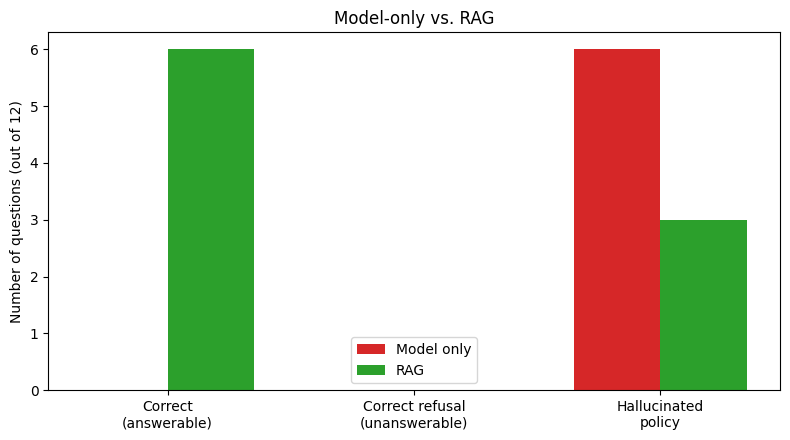

In [15]:
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# 1. Model-only vs RAG
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics_labels = ["Correct\n(answerable)", "Correct refusal\n(unanswerable)", "Hallucinated\npolicy"]
baseline_vals = [
    sum(1 for r in baseline_results.values() if r["verdict"] == "correct"),
    sum(1 for r in baseline_results.values() if r["verdict"] == "correct_refusal"),
    sum(1 for r in baseline_results.values() if r["verdict"] == "hallucinated_policy"),
]
rag_vals = [
    sum(1 for r in rag_results.values() if r["verdict"] == "correct"),
    sum(1 for r in rag_results.values() if r["verdict"] == "correct_refusal"),
    sum(1 for r in rag_results.values() if r["verdict"] == "hallucinated_policy"),
]
x = np.arange(len(metrics_labels))
width = 0.35
ax.bar(x - width / 2, baseline_vals, width, label="Model only", color="tab:red")
ax.bar(x + width / 2, rag_vals, width, label="RAG", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel(f"Number of questions (out of {len(QUESTIONS)})")
ax.set_title("Model-only vs. RAG")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_rag_model_vs_rag.png", dpi=150)
plt.show()

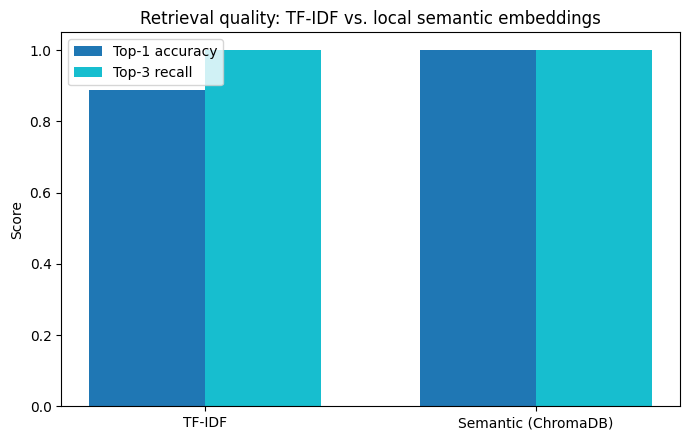

In [16]:
# 2. Retrieval quality: TF-IDF vs semantic
fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ["tfidf", "semantic"]
top1_accs = [sum(r["top1"] for r in retrieval_eval[m]) / len(retrieval_eval[m]) for m in methods]
top3_recalls = [sum(r["top3"] for r in retrieval_eval[m]) / len(retrieval_eval[m]) for m in methods]
x = np.arange(len(methods))
width = 0.35
ax.bar(x - width / 2, top1_accs, width, label="Top-1 accuracy", color="tab:blue")
ax.bar(x + width / 2, top3_recalls, width, label="Top-3 recall", color="tab:cyan")
ax.set_xticks(x)
ax.set_xticklabels(["TF-IDF", "Semantic (ChromaDB)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Retrieval quality: TF-IDF vs. local semantic embeddings")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_rag_retrieval_quality.png", dpi=150)
plt.show()

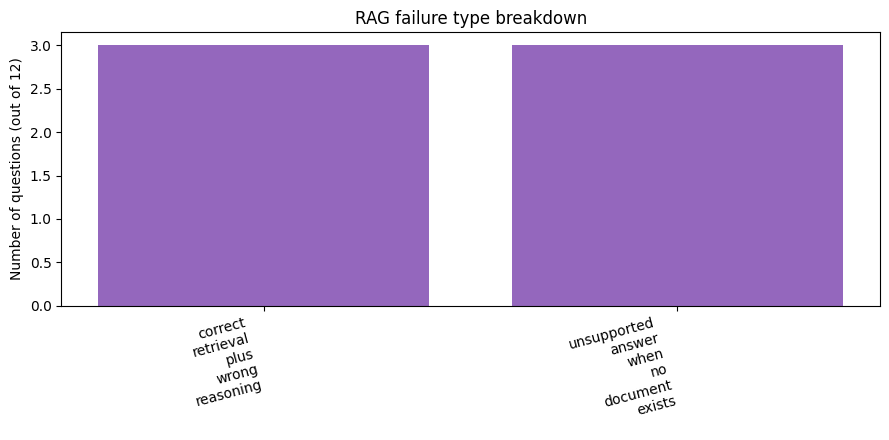

In [17]:
# 3. RAG failure types
fig, ax = plt.subplots(figsize=(9, 4.5))
if rag_failure_counts:
    labels = list(rag_failure_counts.keys())
    counts = list(rag_failure_counts.values())
else:
    labels, counts = ["no failures observed"], [0]
ax.bar([l.replace("_", "\n") for l in labels], counts, color="tab:purple")
ax.set_ylabel(f"Number of questions (out of {len(QUESTIONS)})")
ax.set_title("RAG failure type breakdown")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_rag_failure_types.png", dpi=150)
plt.show()

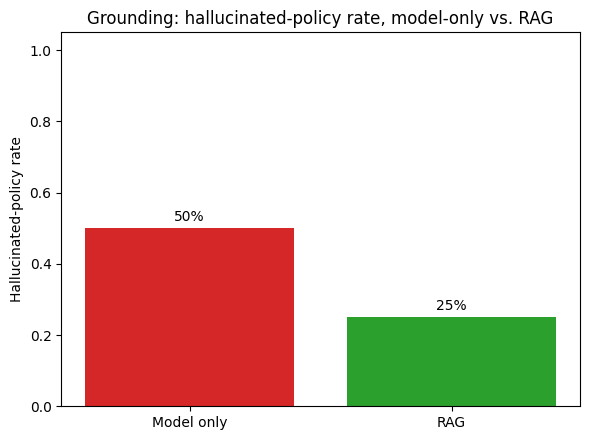

Saved: 08_rag_model_vs_rag.png, 08_rag_retrieval_quality.png, 08_rag_failure_types.png, 08_rag_grounding.png


In [18]:
# 4. Grounding: hallucinated-policy rate, model-only vs RAG
fig, ax = plt.subplots(figsize=(6, 4.5))
hallucination_rate_baseline = sum(1 for r in baseline_results.values() if r["verdict"] == "hallucinated_policy") / len(QUESTIONS)
hallucination_rate_rag = sum(1 for r in rag_results.values() if r["verdict"] == "hallucinated_policy") / len(QUESTIONS)
ax.bar(["Model only", "RAG"], [hallucination_rate_baseline, hallucination_rate_rag], color=["tab:red", "tab:green"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Hallucinated-policy rate")
ax.set_title("Grounding: hallucinated-policy rate, model-only vs. RAG")
for i, v in enumerate([hallucination_rate_baseline, hallucination_rate_rag]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_rag_grounding.png", dpi=150)
plt.show()

print("Saved: 08_rag_model_vs_rag.png, 08_rag_retrieval_quality.png, 08_rag_failure_types.png, 08_rag_grounding.png")

## Post-execution audit (added after the recorded run)

**What this is.** The original run of this notebook saved only verdict labels for its 24 responses (12 questions x 2 configurations); the answer text lived in kernel memory and was never persisted. After the run, the same pipeline was executed again, all 24 answers were saved with the model configuration, generation settings, retrieval scores and citations, and each answer was read against the exact policy text. The evidence is in `results/08_rag_audit_raw_answers.json`. **This is a fresh audit run, not the original experiment.** The recorded outputs and automated scores in this notebook are unchanged; the corrections above are notes added afterward, so the record shows both what was originally reported and what the later review changed.

**How closely the audit run matched the recorded run.** All 12 RAG verdicts and 10 of 12 model-only verdicts were identical. The two differences (Q7, Q12, model-only) were recorded parse failures that parsed on the re-run. RAG answers were stable across runs; model-only wording varies (the same question produced different specific values on different samples), and no seed was set.

**Where the recorded automated label and the manual reading differ** (all other labels agree with the reading):

| Q | Configuration | Recorded label | Manual reading |
|---|---|---|---|
| Q1 | model-only | partially_correct | Wrong: says "Yes" (policy: never) |
| Q3 | model-only | partially_correct | Wrong: gives a review time other than the policy's 30 minutes |
| Q6, Q8 | model-only | partially_correct | Right on the headline "No"; generic |
| Q5, Q9, Q10 | model-only | hallucinated_policy | Hedged or generic non-answers; no invented org-specific value (Q10 offered a general range) |
| Q1, Q8 | RAG | partially_correct | Correct, terse |
| Q7 | RAG | partially_correct | Right direction; says "will" where the policy says "may" |
| Q5 | RAG | correct | Right destination and timing; wrong actor ("the privileged user must escalate") |
| Q11 | RAG | hallucinated_policy | Mixed: correctly says no path is defined, then invents a default attributed to "the general incident response policy" |
| Q10, Q12 | RAG | hallucinated_policy | Fabricated (a 90-day retention rule; a VPN certificate process) |

**Manual tallies (single sampled pass, one reviewer).** RAG, 9 answerable questions: 7 correct as written, 2 right in substance with a wording-level flaw (Q5, Q7), 0 wrong. Model-only, 9 answerable questions: 2 right on the headline but generic (Q6, Q8), 4 wrong on organization-specific facts (Q1, Q2, Q3, Q4), 3 generic or hedged non-answers (Q5, Q7, Q9). Unanswerable questions: no configuration ever set `insufficient_information`; with RAG, none of the three was cleanly declined.

**Citation faithfulness (not measured in the recorded run).** For all 9 answerable questions the RAG answer cited the authoritative document. For the unanswerable questions, the model cited real policy documents for claims those documents do not contain: Q10 cites the incident response policy for a 90-day firewall-log retention rule (that document only covers audit logging of containment actions), and Q12 says its invented VPN process is guided by an Authentication Policy that "mandates" IT approval for new credentials (it contains no such rule). This is a separate failure from retrieving the wrong document and from answering with no citation: the citation makes an unsupported claim look traceable. `score_answer` ignores `source_documents`, so this needs its own check.

**Model-only `hallucinated_policy` label.** For the model-only column it means "answered without flagging insufficient information and did not match the reference," which includes hedged, generic answers as well as confidently wrong ones. It is not evidence of fabricated policy in every case.

**What stands and what does not.** Stands: retrieval never missed the authoritative document (9/9 top-1 with semantic retrieval); the unaided model was right on generic defaults and wrong on organization-specific facts; the model did not decline any unanswerable question; RAG stated a 90-day retention rule that appears in no document. Does not stand: "all three partial answers were correct" (Q7 overstates "may"), "all nine RAG answers were fully correct" (Q5, Q7), and "every remaining failure was a reasoning failure" (the failures observed were abstention and citation faithfulness). The Final summary's reference to Section 12 describes the taxonomy's design, which remains a valid diagnostic; this run's observed failures fell outside its retrieval-versus-reasoning split.

**Limits of the audit.** One sampled pass per configuration, one reviewer, 12 synthetic questions, one quantized model.

## Final summary

**RAG does not change the model's weights. It provides external knowledge at inference time. This is useful for current, customer-specific, or traceable information, but introduces a retrieval layer that must itself be evaluated, secured, versioned, governed, and observed.**

This notebook's own structure is the evidence for that claim: Section 7 evaluated retrieval on its own, before generation ever entered the picture; Section 12 showed that a wrong RAG answer can come from either layer, and they need different fixes; Section 13 showed that retrieval can hand the model two contradictory authoritative facts and something has to decide which one wins, and that something should not be an implicit, unreviewed choice inside a similarity ranking; Section 14 showed that a model's confidence is not the same thing as a policy's authority; and Section 17 showed what has to be logged for any of these failure modes to be diagnosable at all after the fact, rather than just in a notebook where every intermediate value is still sitting in memory. RAG is a genuinely useful answer to "how does a foundation model know about *this* organization" -- but it is a new system with its own failure modes, not a solved problem the moment retrieval is wired up.